# Sprint 1 — EDA Dataset 1 : Medical Text (EN)

**Auteur** : TAYAR Ali  
**Dataset** : [Kaggle — chaitanyakck/medical-text](https://www.kaggle.com/datasets/chaitanyakck/medical-text)  
**Objectif** : Explorer et comprendre la structure du dataset médical anglais avant tout prétraitement.

---


## 0. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
import re
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_PATH    = '../data/raw/dataset1/'
FIGURES_PATH = '../results/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

print('Imports OK')

Imports OK


---
## 1. Chargement du Dataset

In [ ]:
LABEL_NAMES = {
    1: 'Neoplasms',
    2: 'Digestive system diseases',
    3: 'Nervous system diseases',
    4: 'Cardiovascular diseases',
    5: 'General pathological conditions'
}

def load_dat_file(filepath):
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t', 1)
            if len(parts) == 2:
                label, text = parts
                try:
                    records.append({'label': int(label), 'text': text})
                except ValueError:
                    pass
    return pd.DataFrame(records)

df = load_dat_file(os.path.join(DATA_PATH, 'train.dat'))
df['label_name'] = df['label'].map(LABEL_NAMES)

print(f'Total : {len(df):,} lignes')
print(f'Colonnes : {df.columns.tolist()}')
df.head(3)

Total : 14,438 lignes
Colonnes : ['label', 'text', 'label_name']


,label,text,label_name
0,4,Catheterization laboratory events and hospital...,Cardiovascular diseases
1,5,Renal abscess in children. Three cases of rena...,General pathological conditions
2,2,Hyperplastic polyps seen at sigmoidoscopy are ...,Digestive system diseases


---
## 2. Qualité des données

In [4]:
print('=== Valeurs nulles ===')
print(df.isnull().sum())

print('\n=== Doublons ===')
print(f'Lignes dupliquées : {df.duplicated().sum()}')

print('\n=== Textes trop courts (< 10 chars) ===')
print(f'Textes trop courts : {(df["text"].str.len() < 10).sum()}')

=== Valeurs nulles ===
label         0
text          0
label_name    0
dtype: int64

=== Doublons ===
Lignes dupliquées : 0

=== Textes trop courts (< 10 chars) ===
Textes trop courts : 0


---
## 3. Distribution des classes

In [5]:
label_counts = df['label_name'].value_counts()
print(label_counts)
print(f'\nNombre de classes : {df["label"].nunique()}')
print(f'Ratio déséquilibre (max/min) : {label_counts.max() / label_counts.min():.2f}x')

label_name
General pathological conditions    4805
Neoplasms                          3163
Cardiovascular diseases            3051
Nervous system diseases            1925
Digestive system diseases          1494
Name: count, dtype: int64

Nombre de classes : 5
Ratio déséquilibre (max/min) : 3.22x


## 4. Longueur des textes

In [7]:
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

print(df[['word_count', 'char_count']].describe().round(1))
print(f'\n95e percentile (mots) : {int(np.percentile(df["word_count"], 95))}')
print(f'99e percentile (mots) : {int(np.percentile(df["word_count"], 99))}')

       word_count  char_count
count     14438.0     14438.0
mean        179.9      1229.7
std          76.5       507.3
min          24.0       169.0
25%         122.0       849.0
50%         176.0      1209.0
75%         235.0      1588.0
max         596.0      3998.0

95e percentile (mots) : 302
99e percentile (mots) : 383


### Visualisation des longueurs

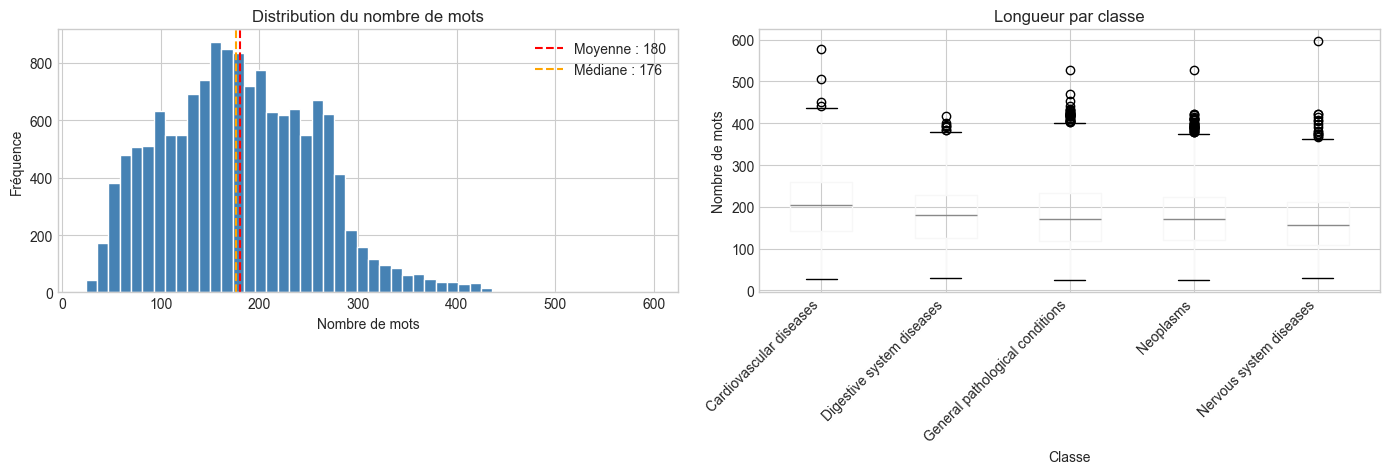

Sauvegardé : ds1_text_lengths.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme word count
axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Moyenne : {df["word_count"].mean():.0f}')
axes[0].axvline(df['word_count'].median(), color='orange', linestyle='--', label=f'Médiane : {df["word_count"].median():.0f}')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution du nombre de mots')
axes[0].legend()

# Boxplot par classe
df.boxplot(column='word_count', by='label_name', ax=axes[1])
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre de mots')
axes[1].set_title('Longueur par classe')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds1_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : ds1_text_lengths.png')

## 5. Analyse du vocabulaire

In [10]:
STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','being','have','has','had','do',
    'does','did','will','would','could','should','may','might','that','this',
    'these','those','it','its','as','by','from','into','not','no','we','our',
    'they','their','which','who','what','when','where','how','after','before',
    'between','than','both','also','all','each','than','were','been','there'
])

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

all_words = []
for text in df['text']:
    all_words.extend(simple_tokenize(text))

word_freq = Counter(all_words)

print(f'Taille vocabulaire brut : {len(word_freq):,} mots uniques')
print(f'Total tokens            : {sum(word_freq.values()):,}')
print(f'\nTop 20 mots :')
for word, count in word_freq.most_common(20):
    print(f'  {word:<25} {count:>6,}')

Taille vocabulaire brut : 43,974 mots uniques
Total tokens            : 1,542,241

Top 20 mots :
  patients                  34,723
  less                       7,480
  disease                    7,287
  group                      6,333
  treatment                  6,067
  during                     5,525
  study                      5,507
  two                        5,099
  one                        4,804
  cases                      4,478
  patient                    4,445
  blood                      4,425
  years                      4,406
  clinical                   4,343
  cells                      4,219
  results                    4,165
  more                       4,110
  therapy                    3,751
  normal                     3,653
  associated                 3,631


### Visualisation du vocabulaire

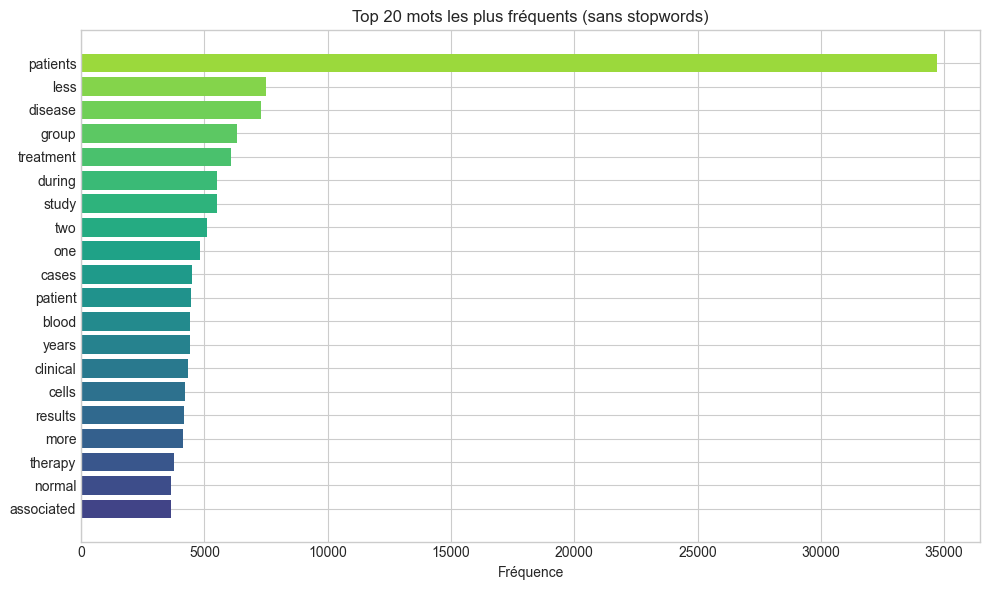

Sauvegardé : ds1_top_words.png


In [11]:
top20 = word_freq.most_common(20)
words20, freqs20 = zip(*top20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(reversed(words20)), list(reversed(freqs20)),
        color=plt.cm.viridis(np.linspace(0.2, 0.85, 20)))
ax.set_xlabel('Fréquence')
ax.set_title('Top 20 mots les plus fréquents (sans stopwords)')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds1_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : ds1_top_words.png')

## 6. Word Clouds

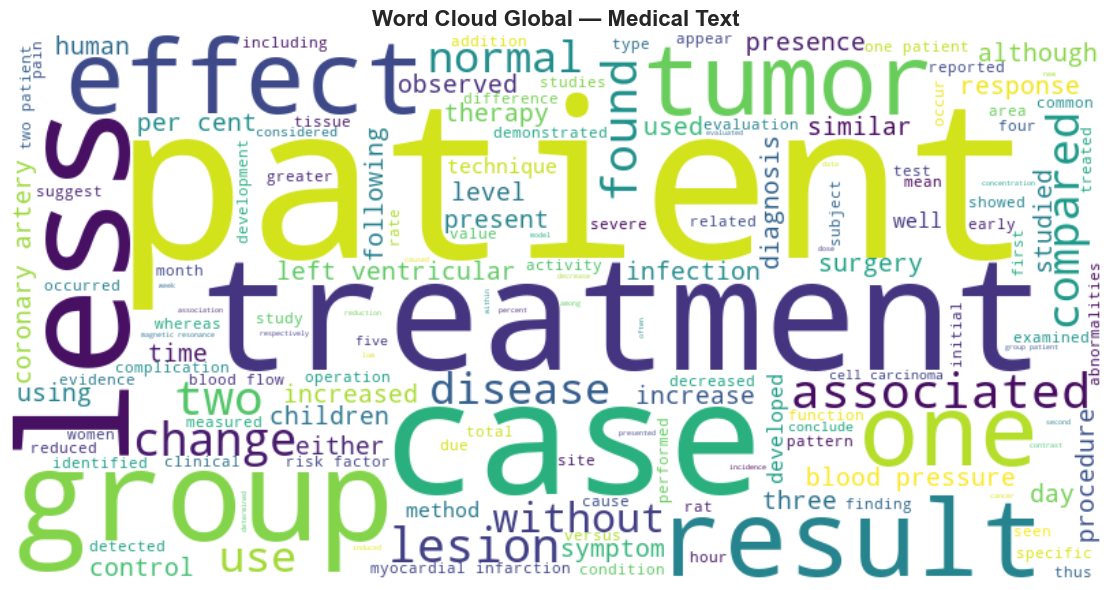

Sauvegardé : ds1_wordcloud_global.png


In [13]:
corpus = ' '.join([' '.join(simple_tokenize(t)) for t in df['text']])

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='viridis', max_words=150).generate(corpus)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud Global — Medical Text', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds1_wordcloud_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : ds1_wordcloud_global.png')

### Word Clouds par classe

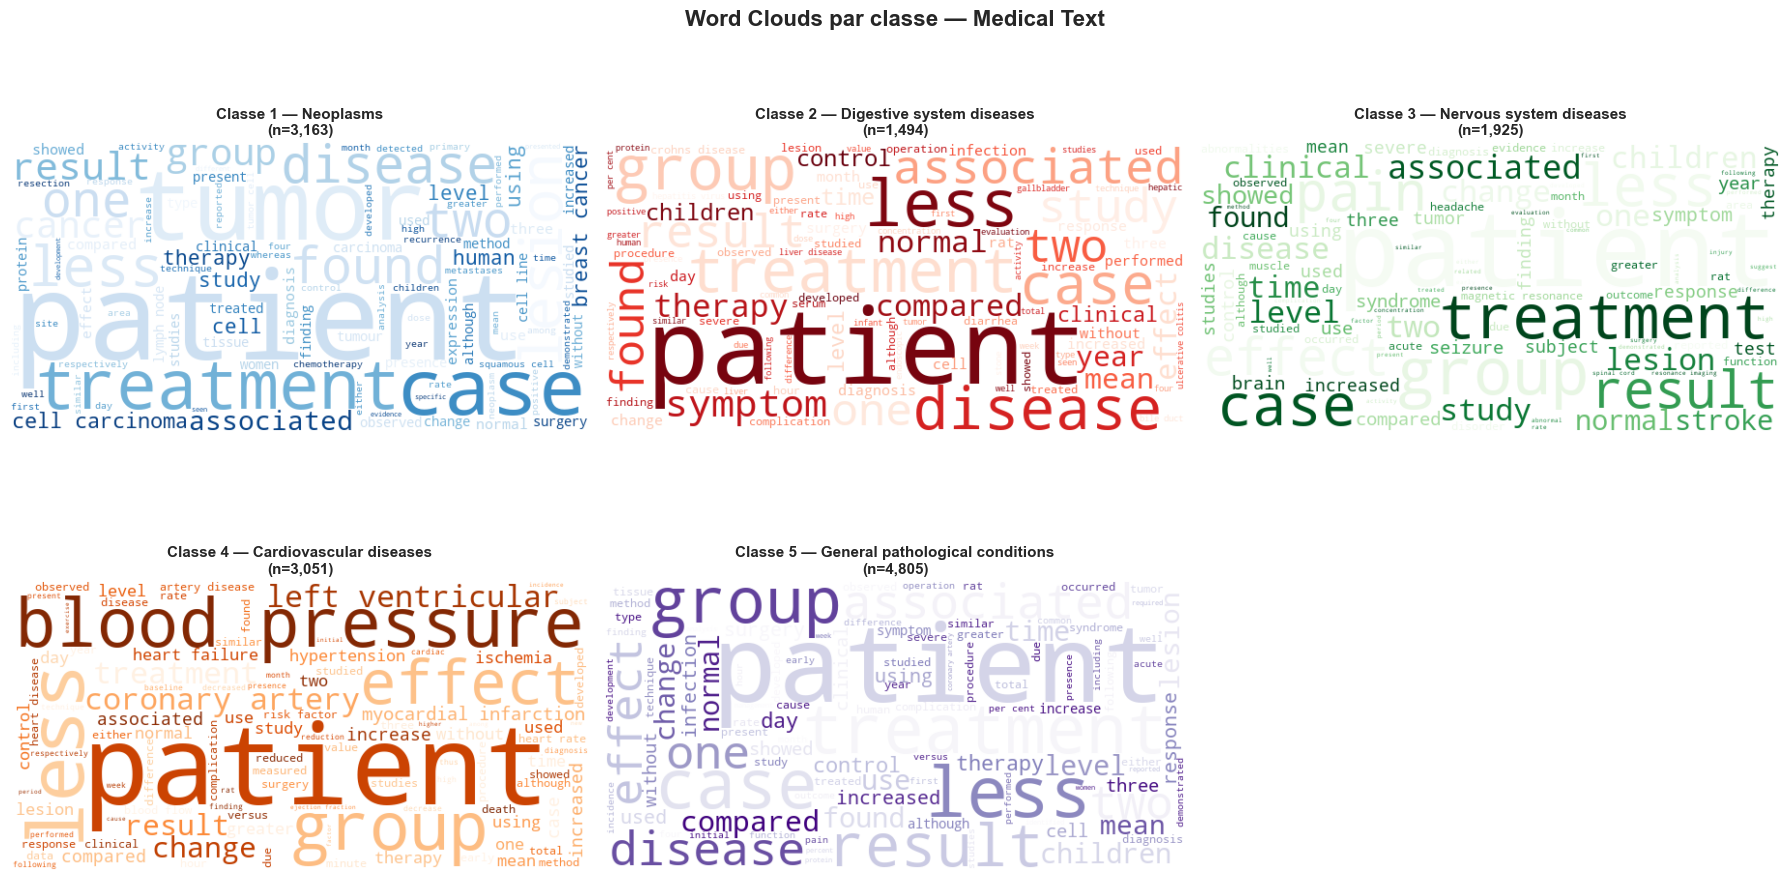

Sauvegardé : ds1_wordclouds_per_class.png


In [15]:
classes     = sorted(df['label'].unique())
colormaps   = ['Blues', 'Reds', 'Greens', 'Oranges', 'Purples']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    corpus_cls = ' '.join([' '.join(simple_tokenize(t)) 
                           for t in df[df['label'] == cls]['text']])
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=colormaps[i], max_words=100).generate(corpus_cls)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Classe {cls} — {LABEL_NAMES[cls]}\n(n={len(df[df["label"]==cls]):,})',
                      fontsize=11, fontweight='bold')

axes[5].set_visible(False)

plt.suptitle('Word Clouds par classe — Medical Text', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds1_wordclouds_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : ds1_wordclouds_per_class.png')

## 7. Résumé & Conclusions

In [16]:
maxlen = int(np.percentile(df['word_count'], 95))

print('=' * 55)
print('     RÉSUMÉ EDA — DATASET 1 MEDICAL TEXT')
print('=' * 55)
print(f"""
DATASET
  Total échantillons  : {len(df):,}
  Nombre de classes   : {df['label'].nunique()}
  Ratio déséquilibre  : {label_counts.max() / label_counts.min():.2f}x

LONGUEUR DES TEXTES
  Moyenne             : {df['word_count'].mean():.0f} mots
  Médiane             : {df['word_count'].median():.0f} mots
  Max                 : {df['word_count'].max()} mots
  → maxlen padding    : {maxlen} mots (95e percentile)

VOCABULAIRE
  Mots uniques (brut) : {len(word_freq):,}
  → vocab Keras       : 10,000 (top words)

TODO SPRINT 2
  → Stopwords NLTK complets + lemmatisation
  → maxlen = {maxlen}
  → class_weight (ratio 3.22x)
  → vocab_size = 10,000
""")
print('=' * 55)

# Sauvegarder le dataset nettoyé
df.to_csv('../data/processed/ds1_eda.csv', index=False)
print('Sauvegardé : data/processed/ds1_eda.csv')

     RÉSUMÉ EDA — DATASET 1 MEDICAL TEXT

DATASET
  Total échantillons  : 14,438
  Nombre de classes   : 5
  Ratio déséquilibre  : 3.22x

LONGUEUR DES TEXTES
  Moyenne             : 180 mots
  Médiane             : 176 mots
  Max                 : 596 mots
  → maxlen padding    : 302 mots (95e percentile)

VOCABULAIRE
  Mots uniques (brut) : 43,974
  → vocab Keras       : 10,000 (top words)

TODO SPRINT 2
  → Stopwords NLTK complets + lemmatisation
  → maxlen = 302
  → class_weight (ratio 3.22x)
  → vocab_size = 10,000

Sauvegardé : data/processed/ds1_eda.csv
